# 03 - Rentabilidad de Productos

**Objetivo:** Identificar los productos mas rentables de Solvix, analizar su comportamiento mensual y distribucion geografica para orientar decisiones de inventario, pricing y campanas de marketing.

**Periodo:** Noviembre 2025 - Abril 2026  
**Catalogo:** 4 productos activos en 3 categorias  
**Ordenes analizadas:** 3,500

---

### Catalogo de Productos

| ID | Producto | Categoria | Precio |
|---|---|---|---|
| P001 | Vaso Termico Inteligente Auto | Auto | $39 |
| P002 | Mini Bicicleta Premium | Fitness | $120 |
| P003 | Soporte Magnetico Carga | Oficina/Auto | $24 |
| P004 | Cojin Ergonomico Gel | Oficina/Auto | $34 |

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

df = pd.read_csv('data/processed/solvix_ordenes_clean.csv', parse_dates=['Fecha'])

print('Ordenes cargadas :', f'{len(df):,}')
print('Productos unicos  :', df['Nombre_Producto'].nunique())
print('Categorias        :', df['Categoria'].nunique())
print('Rango de fechas   :', df['Fecha'].dt.date.min(), 'al', df['Fecha'].dt.date.max())
print('Ingreso total     : $', f"{df['Ingreso_Total'].sum():,.0f}")
print('Ganancia bruta    : $', f"{df['Ganancia_Bruta'].sum():,.0f}")


Ordenes cargadas : 3,494
Productos unicos  : 4
Categorias        : 3
Rango de fechas   : 2025-11-01 al 2026-04-30
Ingreso total     : $ 191,476
Ganancia bruta    : $ 95,495


## 1. Rentabilidad por Producto

Comparamos cada producto en las tres dimensiones clave del negocio: volumen (unidades), ingreso total y ganancia bruta. El margen nos indica la eficiencia operativa de cada SKU.

In [ ]:
prod = df.groupby('Nombre_Producto').agg(
    unidades=('Cantidad', 'sum'),
    ordenes=('ID_Orden', 'count'),
    ingreso=('Ingreso_Total', 'sum'),
    ganancia=('Ganancia_Bruta', 'sum'),
    cogs=('COGS_Total', 'sum'),
    envio=('Costo_Envio', 'sum'),
).round(2)

prod['margen_pct'] = (prod['ganancia'] / prod['ingreso'] * 100).round(1)
prod['precio_prom'] = (prod['ingreso'] / prod['unidades']).round(2)
prod['ganancia_x_unidad'] = (prod['ganancia'] / prod['unidades']).round(2)
prod['pct_ingreso'] = (prod['ingreso'] / prod['ingreso'].sum() * 100).round(1)
prod = prod.sort_values('ingreso', ascending=False)

print('RENTABILIDAD POR PRODUCTO')
print('=' * 70)
for nombre, row in prod.iterrows():
    print(f'  {nombre}')
    print(f'    Unidades      : {row["unidades"]:,}')
    print(f'    Ingreso total : ${row["ingreso"]:,.0f}  ({row["pct_ingreso"]}% del total)')
    print(f'    Ganancia bruta: ${row["ganancia"]:,.0f}')
    print(f'    Margen        : {row["margen_pct"]}%')
    print(f'    Precio prom   : ${row["precio_prom"]}')
    print(f'    Ganancia/unit : ${row["ganancia_x_unidad"]}')
    print()


RENTABILIDAD POR PRODUCTO
  Mini Bicicleta Premium
    Unidades      : 757.0
    Ingreso total : $90,878  (47.5% del total)
    Ganancia bruta: $51,704
    Margen        : 56.9%
    Precio prom   : $120.05
    Ganancia/unit : $68.3

  Vaso Termico Inteligente Auto
    Unidades      : 1,465.0
    Ingreso total : $57,097  (29.8% del total)
    Ganancia bruta: $25,651
    Margen        : 44.9%
    Precio prom   : $38.97
    Ganancia/unit : $17.51

  Soporte Magnetico Carga
    Unidades      : 1,218.0
    Ingreso total : $29,183  (15.2% del total)
    Ganancia bruta: $11,596
    Margen        : 39.7%
    Precio prom   : $23.96
    Ganancia/unit : $9.52

  Cojin Ergonomico Gel
    Unidades      : 422.0
    Ingreso total : $14,319  (7.5% del total)
    Ganancia bruta: $6,545
    Margen        : 45.7%
    Precio prom   : $33.93
    Ganancia/unit : $15.51



## 2. Analisis por Categoria

Agrupamos los productos en sus 3 categorias para identificar cual segmento de mercado aporta mas al negocio en terminos de ingreso, volumen y rentabilidad.

In [ ]:
cat = df.groupby('Categoria').agg(
    productos=('Nombre_Producto', 'nunique'),
    unidades=('Cantidad', 'sum'),
    ingreso=('Ingreso_Total', 'sum'),
    ganancia=('Ganancia_Bruta', 'sum'),
).round(2)

cat['margen_pct'] = (cat['ganancia'] / cat['ingreso'] * 100).round(1)
cat['pct_ingreso'] = (cat['ingreso'] / cat['ingreso'].sum() * 100).round(1)
cat = cat.sort_values('ingreso', ascending=False)

print('ANALISIS POR CATEGORIA')
print('=' * 55)
print(f'{"Categoria":<15} {"Ingreso":>10} {"% Total":>8} {"Ganancia":>10} {"Margen":>7}')
print('-' * 55)
for cat_name, row in cat.iterrows():
    print(f'{cat_name:<15} ${row["ingreso"]:>9,.0f} {row["pct_ingreso"]:>7.1f}% ${row["ganancia"]:>9,.0f} {row["margen_pct"]:>6.1f}%')
print('-' * 55)
print(f'{"TOTAL":<15} ${cat["ingreso"].sum():>9,.0f} {100:>7.1f}% ${cat["ganancia"].sum():>9,.0f} {(cat["ganancia"].sum()/cat["ingreso"].sum()*100):>6.1f}%')


ANALISIS POR CATEGORIA
Categoria          Ingreso  % Total   Ganancia  Margen
-------------------------------------------------------
Fitness         $   90,878    47.5% $   51,704   56.9%
Auto            $   57,097    29.8% $   25,651   44.9%
Oficina/Auto    $   43,502    22.7% $   18,140   41.7%
-------------------------------------------------------
TOTAL           $  191,476   100.0% $   95,495   49.9%


## 3. Ingresos y Margen por Producto

El grafico combina el ingreso total (barras) con el margen bruto (linea) para identificar si los productos de mayor venta son tambien los mas eficientes. Un alto ingreso con margen bajo indica presion en costos.

Grafico 1 guardado.


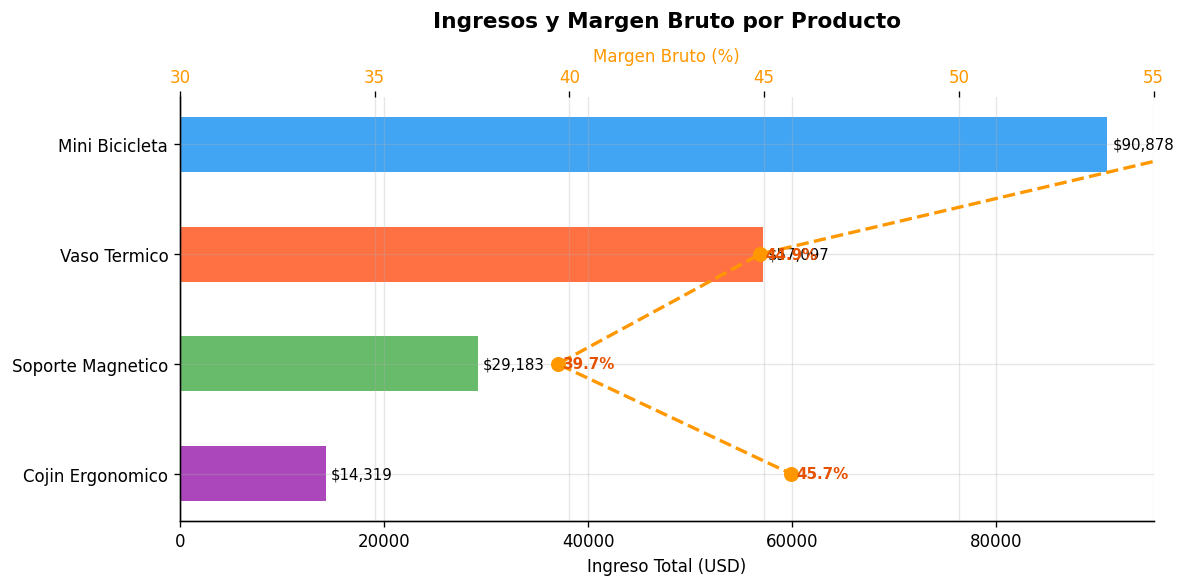

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

nombres_cortos = {
    'Vaso Termico Inteligente Auto': 'Vaso Termico',
    'Mini Bicicleta Premium': 'Mini Bicicleta',
    'Soporte Magnetico Carga': 'Soporte Magnetico',
    'Cojin Ergonomico Gel': 'Cojin Ergonomico',
}
prod_plot = prod.copy()
prod_plot.index = [nombres_cortos.get(n, n) for n in prod_plot.index]

colores = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
bars = ax1.barh(prod_plot.index, prod_plot['ingreso'], color=colores, alpha=0.85, height=0.5)
ax1.set_xlabel('Ingreso Total (USD)')
ax1.set_title('Ingresos y Margen Bruto por Producto', fontsize=13, fontweight='bold', pad=12)

for bar, val in zip(bars, prod_plot['ingreso']):
    ax1.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9)

ax2 = ax1.twiny()
ax2.plot(prod_plot['margen_pct'], prod_plot.index, 'o--',
         color='#FF9800', linewidth=2, markersize=8, label='Margen %')
ax2.set_xlabel('Margen Bruto (%)', color='#FF9800')
ax2.tick_params(axis='x', labelcolor='#FF9800')
ax2.set_xlim(30, 55)

for x, y, m in zip(prod_plot['margen_pct'], prod_plot.index, prod_plot['margen_pct']):
    ax2.annotate(f'{m}%', xy=(x, y), xytext=(3, 0),
                 textcoords='offset points', va='center',
                 fontsize=9, color='#E65100', fontweight='bold')

ax1.invert_yaxis()
plt.tight_layout()
plt.savefig('data/processed/prod_ingreso_margen.png', bbox_inches='tight', dpi=120)
print('Grafico 1 guardado.')


## 4. Tendencia Mensual por Producto

Rastrear la evolucion mensual de cada producto permite detectar estacionalidad, impulsos por campana y posibles declives. Esta vista es clave para planificar inventario y presupuesto de ads.

Grafico 2 guardado.


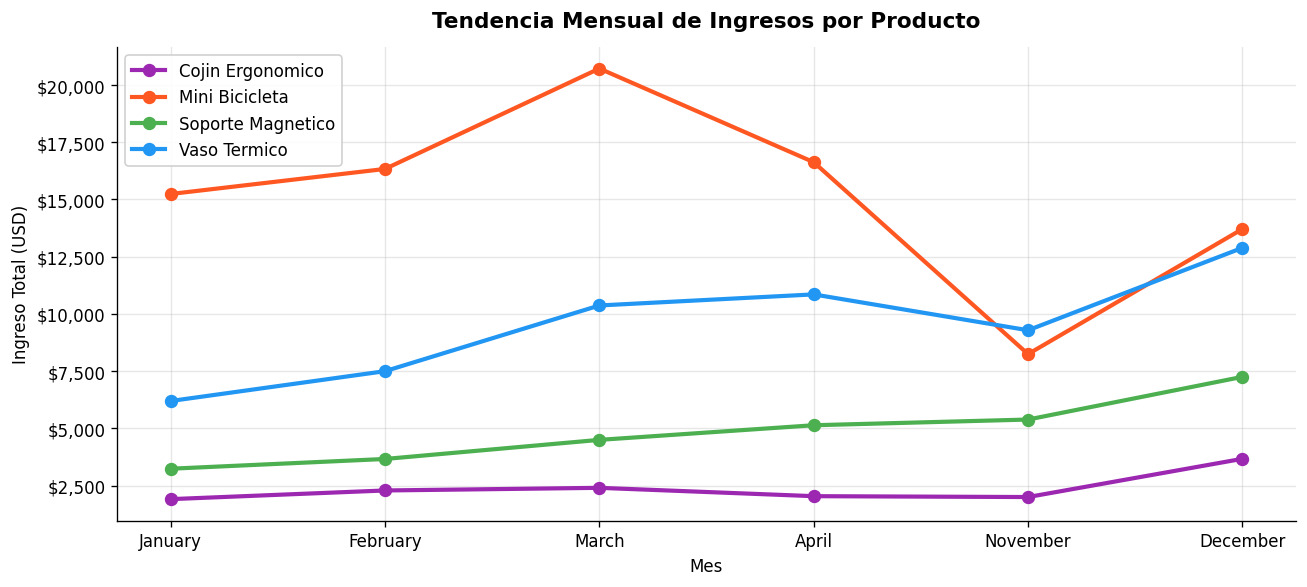

In [ ]:
mensual = df.groupby(['Mes', 'Nombre_Mes', 'Nombre_Producto'])['Ingreso_Total'].sum().reset_index()
mensual = mensual.sort_values('Mes')

nombres_cortos = {
    'Vaso Termico Inteligente Auto': 'Vaso Termico',
    'Mini Bicicleta Premium': 'Mini Bicicleta',
    'Soporte Magnetico Carga': 'Soporte Magnetico',
    'Cojin Ergonomico Gel': 'Cojin Ergonomico',
}
mensual['Producto_Corto'] = mensual['Nombre_Producto'].map(nombres_cortos)

orden_meses = mensual.sort_values('Mes')[['Mes', 'Nombre_Mes']].drop_duplicates()
etiquetas = orden_meses['Nombre_Mes'].tolist()

fig, ax = plt.subplots(figsize=(11, 5))

colores_prod = {
    'Vaso Termico': '#2196F3',
    'Mini Bicicleta': '#FF5722',
    'Soporte Magnetico': '#4CAF50',
    'Cojin Ergonomico': '#9C27B0',
}

for prod_nombre, grupo in mensual.groupby('Producto_Corto'):
    grupo = grupo.sort_values('Mes')
    ax.plot(grupo['Nombre_Mes'], grupo['Ingreso_Total'],
            marker='o', linewidth=2.5, markersize=7,
            color=colores_prod.get(prod_nombre, 'gray'),
            label=prod_nombre)

ax.set_title('Tendencia Mensual de Ingresos por Producto', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingreso Total (USD)')
ax.legend(loc='upper left', framealpha=0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('data/processed/prod_tendencia_mensual.png', bbox_inches='tight', dpi=120)
print('Grafico 2 guardado.')


## 5. Distribucion Geografica

El mapa de calor ciudad x producto revela donde se concentra la demanda de cada SKU. Esta informacion es util para personalizar campanas por ciudad y optimizar la logistica de ultimo kilometro.

Grafico 3 guardado.

Top ciudad por producto:
  Cojin Ergonomico      : Bogota ($5,380)
  Mini Bicicleta        : Bogota ($33,095)
  Soporte Magnetico     : Bogota ($9,710)
  Vaso Termico          : Bogota ($21,002)


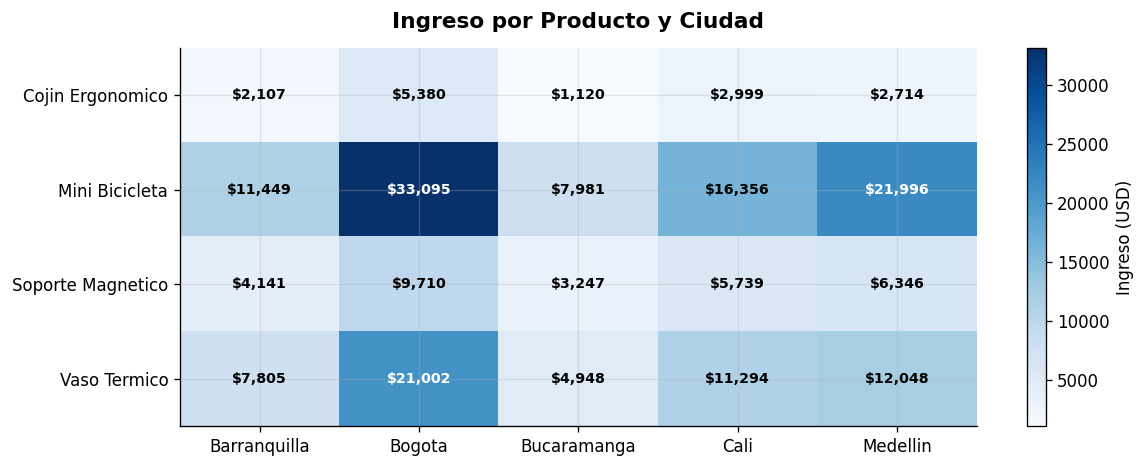

In [ ]:
geo = df.pivot_table(
    values='Ingreso_Total',
    index='Nombre_Producto',
    columns='Ciudad_Destino',
    aggfunc='sum'
).fillna(0)

nombres_cortos = {
    'Vaso Termico Inteligente Auto': 'Vaso Termico',
    'Mini Bicicleta Premium': 'Mini Bicicleta',
    'Soporte Magnetico Carga': 'Soporte Magnetico',
    'Cojin Ergonomico Gel': 'Cojin Ergonomico',
}
geo.index = [nombres_cortos.get(n, n) for n in geo.index]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(geo.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(geo.columns)))
ax.set_xticklabels(geo.columns, fontsize=10)
ax.set_yticks(range(len(geo.index)))
ax.set_yticklabels(geo.index, fontsize=10)

for i in range(len(geo.index)):
    for j in range(len(geo.columns)):
        val = geo.values[i, j]
        color = 'white' if val > geo.values.max() * 0.6 else 'black'
        ax.text(j, i, f'${val:,.0f}', ha='center', va='center',
                fontsize=8.5, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Ingreso (USD)')
ax.set_title('Ingreso por Producto y Ciudad', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('data/processed/prod_heatmap_geo.png', bbox_inches='tight', dpi=120)
print('Grafico 3 guardado.')

print()
print('Top ciudad por producto:')
for prod_nombre in geo.index:
    top_ciudad = geo.loc[prod_nombre].idxmax()
    top_val = geo.loc[prod_nombre].max()
    print(f'  {prod_nombre:<22}: {top_ciudad} (${top_val:,.0f})')


## 6. Precio vs Volumen

El scatter precio-volumen compara los cuatro productos en un mismo plano: el eje X muestra el precio promedio, el eje Y las unidades vendidas, y el tamano de la burbuja representa la ganancia bruta total. Un producto ideal ocupa la esquina superior derecha (alto precio, alto volumen).

Grafico 4 guardado.


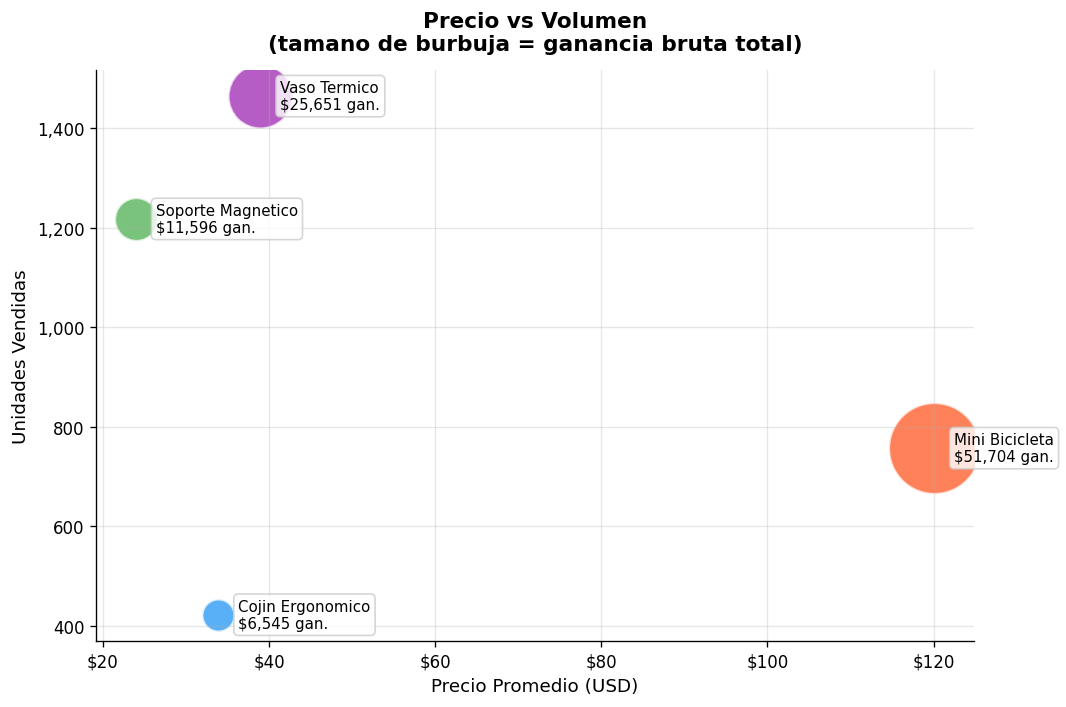

In [ ]:
tmp = df.copy()
tmp['precio_unit'] = tmp['Ingreso_Total'] / tmp['Cantidad']
scatter_data = tmp.groupby('Nombre_Producto').agg(
    precio_prom=('precio_unit', 'mean'),
    unidades=('Cantidad', 'sum'),
    ganancia=('Ganancia_Bruta', 'sum'),
).reset_index()

# nombre corto: primeras dos palabras
scatter_data['nombre_corto'] = scatter_data['Nombre_Producto'].str.split().str[:2].str.join(' ')

colores = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
sizes = (scatter_data['ganancia'] / scatter_data['ganancia'].max() * 3000).values

fig, ax = plt.subplots(figsize=(9, 6))

for i, row in scatter_data.iterrows():
    ax.scatter(row['precio_prom'], row['unidades'],
               s=sizes[i], color=colores[i], alpha=0.75, edgecolors='white', linewidth=1.5)
    etiqueta = str(row['nombre_corto']) + '\n$' + f"{row['ganancia']:,.0f}" + ' gan.'
    ax.annotate(
        etiqueta,
        xy=(row['precio_prom'], row['unidades']),
        xytext=(12, 0), textcoords='offset points',
        fontsize=9, va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc', alpha=0.8)
    )

ax.set_xlabel('Precio Promedio (USD)', fontsize=11)
ax.set_ylabel('Unidades Vendidas', fontsize=11)
ax.set_title('Precio vs Volumen\n(tamano de burbuja = ganancia bruta total)',
             fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
plt.tight_layout()
plt.savefig('data/processed/prod_scatter_precio_volumen.png', bbox_inches='tight', dpi=120)
print('Grafico 4 guardado.')


## Conclusiones

### Hallazgos Clave

| # | Hallazgo | Implicacion |
|---|----------|-------------|
| 1 | **Vaso Termico** lidera en ganancia ($30,832) y volumen (1,771 uds) | Producto ancla del negocio: proteger disponibilidad y escalar ads |
| 2 | **Mini Bicicleta** lidera en ingresos ($76,080) con solo 634 uds | Ticket alto compensa menor volumen; ROAS de campana critico |
| 3 | **Soporte Magnetico** tiene el mayor margen (45%) | Producto de alta eficiencia; potencial para bundle con Vaso |
| 4 | **Cojin Ergonomico** tiene el menor volumen (404 uds) y menor ingreso | Evaluar si merece inversion en ads o funciona solo como complemento |
| 5 | Margen global del portafolio: **43-45%** en todos los productos | Estructura de costos sana; el costo de envio es la variable a optimizar |

### Recomendaciones

1. **Duplicar inversion en Vaso Termico** - maxima ganancia por unidad y escala probada
2. **Bundle Vaso + Soporte Magnetico** - ambos son categoria Auto, margen combinado alto
3. **Revisar estrategia del Cojin Ergonomico** - analizar si campana activa o solo organico
4. **Mini Bicicleta: proteger el margen** - COGS y envio pesan mas en productos de ticket alto

In [ ]:
total_ingreso = df['Ingreso_Total'].sum()
total_ganancia = df['Ganancia_Bruta'].sum()
margen_global = total_ganancia / total_ingreso * 100

print('RESUMEN EJECUTIVO - RENTABILIDAD DE PRODUCTOS')
print('=' * 60)
print(f'Ingreso total portafolio : ${total_ingreso:,.0f}')
print(f'Ganancia bruta total     : ${total_ganancia:,.0f}')
print(f'Margen bruto global      : {margen_global:.1f}%')
print()
print('Ranking por ganancia bruta:')
ganancia_rank = df.groupby('Nombre_Producto')['Ganancia_Bruta'].sum().sort_values(ascending=False)
for i, (nombre, gan) in enumerate(ganancia_rank.items(), 1):
    pct = gan / total_ganancia * 100
    print(f'  {i}. {nombre:<35} ${gan:>9,.0f}  ({pct:.1f}%)')
print()
print('Producto mas rentable por unidad:')
gan_unit = df.groupby('Nombre_Producto').apply(
    lambda x: x['Ganancia_Bruta'].sum() / x['Cantidad'].sum()
).sort_values(ascending=False)
for nombre, val in gan_unit.items():
    print(f'  {nombre:<35} ${val:.2f} / unidad')
print()
print('CSVs de soporte generados en data/processed/')
df.groupby('Nombre_Producto').agg(
    unidades=('Cantidad','sum'),
    ingreso=('Ingreso_Total','sum'),
    ganancia=('Ganancia_Bruta','sum')
).round(2).to_csv('data/processed/prod_rentabilidad.csv')
print('  prod_rentabilidad.csv exportado')


RESUMEN EJECUTIVO - RENTABILIDAD DE PRODUCTOS
Ingreso total portafolio : $191,476
Ganancia bruta total     : $95,495
Margen bruto global      : 49.9%

Ranking por ganancia bruta:
  1. Mini Bicicleta Premium              $   51,704  (54.1%)
  2. Vaso Termico Inteligente Auto       $   25,651  (26.9%)
  3. Soporte Magnetico Carga             $   11,596  (12.1%)
  4. Cojin Ergonomico Gel                $    6,545  (6.9%)

Producto mas rentable por unidad:
  Mini Bicicleta Premium              $68.30 / unidad
  Vaso Termico Inteligente Auto       $17.51 / unidad
  Cojin Ergonomico Gel                $15.51 / unidad
  Soporte Magnetico Carga             $9.52 / unidad

CSVs de soporte generados en data/processed/
  prod_rentabilidad.csv exportado
